In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import shap
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"]    = "serif"
sns.set_style("whitegrid")

print("All imports successful")

All imports successful


In [2]:
import os

DATA_DIR = r"C:\Users\stunn\galamsey_thesis\data"

expected_files = [
    "sentinel2_ghana_2019_2024.csv",
    "sentinel5p_aerosol_2019_2024.csv",
    "sentinel5p_no2_2019_2024.csv",
    "sentinel5p_so2_2019_2024.csv"
]

print("Checking data folder...")
for f in expected_files:
    path = os.path.join(DATA_DIR, f)
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"  ✓ {f}  ({size/1024:.1f} KB)")
    else:
        print(f"  ✗ MISSING: {f}")

Checking data folder...
  ✓ sentinel2_ghana_2019_2024.csv  (378.9 KB)
  ✓ sentinel5p_aerosol_2019_2024.csv  (143.5 KB)
  ✓ sentinel5p_no2_2019_2024.csv  (128.9 KB)
  ✓ sentinel5p_so2_2019_2024.csv  (128.9 KB)


In [3]:
# Load all four datasets
df_s2      = pd.read_csv(os.path.join(DATA_DIR, "sentinel2_ghana_2019_2024.csv"))
df_aerosol = pd.read_csv(os.path.join(DATA_DIR, "sentinel5p_aerosol_2019_2024.csv"))
df_no2     = pd.read_csv(os.path.join(DATA_DIR, "sentinel5p_no2_2019_2024.csv"))
df_so2     = pd.read_csv(os.path.join(DATA_DIR, "sentinel5p_so2_2019_2024.csv"))

# Quick inspection of each
for name, df in [("Sentinel-2", df_s2), 
                 ("Aerosol",    df_aerosol), 
                 ("NO2",        df_no2), 
                 ("SO2",        df_so2)]:
    print(f"{'='*40}")
    print(f"{name}")
    print(f"  Shape:   {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Sample districts: {df['ADM2_NAME'].unique()[:5].tolist()}")
    print(f"  Years:   {sorted(df['year'].unique().tolist())}")
    print(f"  Months:  {sorted(df['month'].unique().tolist())}")
    print()

Sentinel-2
  Shape:   (3744, 9)
  Columns: ['ADM1_NAME', 'ADM2_NAME', 'year', 'month', 'n_images', 'NDVI', 'BSI', 'MNDWI', 'NDMI']
  Sample districts: ['Obuasi Municipal', 'Atwima Nwabiagya', 'Atwima Mponua', 'Adansi South', 'Adansi North']
  Years:   [2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0]
  Months:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]

Aerosol
  Shape:   (3744, 6)
  Columns: ['ADM1_NAME', 'ADM2_NAME', 'year', 'month', 'n_images', 'absorbing_aerosol_index']
  Sample districts: ['Obuasi Municipal', 'Atwima Nwabiagya', 'Atwima Mponua', 'Adansi South', 'Adansi North']
  Years:   [2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0]
  Months:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]

NO2
  Shape:   (3744, 5)
  Columns: ['ADM1_NAME', 'ADM2_NAME', 'year', 'month', 'tropospheric_NO2_column_number_density']
  Sample districts: ['Obuasi Municipal', 'Atwima Nwabiagya', 'Atwima Mponua', 'Adansi South', 'Adansi North']
  Years:   [2019.0, 20

In [5]:
# Merge all four datasets into one master dataframe
df = df_s2.merge(
    df_aerosol[["ADM1_NAME", "ADM2_NAME", "year", "month", 
                "absorbing_aerosol_index"]],
    on=["ADM1_NAME", "ADM2_NAME", "year", "month"],
    how="left"
).merge(
    df_no2[["ADM1_NAME", "ADM2_NAME", "year", "month",
            "tropospheric_NO2_column_number_density"]],
    on=["ADM1_NAME", "ADM2_NAME", "year", "month"],
    how="left"
).merge(
    df_so2[["ADM1_NAME", "ADM2_NAME", "year", "month",
            "SO2_column_number_density"]],
    on=["ADM1_NAME", "ADM2_NAME", "year", "month"],
    how="left"
)

# Rename columns to cleaner names
df = df.rename(columns={
    "ADM1_NAME": "region",
    "ADM2_NAME": "district",
    "absorbing_aerosol_index": "aerosol_index",
    "tropospheric_NO2_column_number_density": "no2_mean",
    "SO2_column_number_density": "so2_mean"
})

# Convert year and month to integers
df["year"]  = df["year"].astype(int)
df["month"] = df["month"].astype(int)

# Create a proper date column
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" + 
    df["month"].astype(str).str.zfill(2) + "-01"
)

print(f"Master dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nSample:")
display(df.head())

Master dataset shape: (3744, 13)

Columns: ['region', 'district', 'year', 'month', 'n_images', 'NDVI', 'BSI', 'MNDWI', 'NDMI', 'aerosol_index', 'no2_mean', 'so2_mean', 'date']

Missing values per column:
region              0
district            0
year                0
month               0
n_images            0
NDVI              638
BSI               638
MNDWI             638
NDMI              638
aerosol_index    3744
no2_mean         3744
so2_mean         3744
date                0
dtype: int64

Sample:


,region,district,year,month,n_images,NDVI,BSI,MNDWI,NDMI,aerosol_index,no2_mean,so2_mean,date
0,Ashanti,Obuasi Municipal,2019,1,91,0.509980,-0.047464,-0.411182,0.091518,NaN,NaN,NaN,2019-01-01
1,Ashanti,Atwima Nwabiagya,2019,1,91,0.555045,-0.018865,-0.499196,0.060050,NaN,NaN,NaN,2019-01-01
2,Ashanti,Atwima Mponua,2019,1,91,0.660704,-0.109346,-0.501558,0.153163,NaN,NaN,NaN,2019-01-01
3,Ashanti,Adansi South,2019,1,91,0.595789,-0.100998,-0.431465,0.147842,NaN,NaN,NaN,2019-01-01
4,Ashanti,Adansi North,2019,1,91,0.631269,-0.105893,-0.465203,0.150181,NaN,NaN,NaN,2019-01-01


In [6]:
# Check if district names match between datasets
s2_districts      = set(df_s2["ADM2_NAME"].unique())
aerosol_districts = set(df_aerosol["ADM2_NAME"].unique())

print(f"Sentinel-2 districts:  {len(s2_districts)}")
print(f"Aerosol districts:     {len(aerosol_districts)}")
print(f"Districts in S2 but NOT in aerosol:")
print(s2_districts - aerosol_districts)
print(f"\nDistricts in aerosol but NOT in S2:")
print(aerosol_districts - s2_districts)

Sentinel-2 districts:  52
Aerosol districts:     52
Districts in S2 but NOT in aerosol:
set()

Districts in aerosol but NOT in S2:
set()


In [7]:
# Check data types and sample values in each dataset
print("Sentinel-2 dtypes:")
print(df_s2[["year", "month"]].dtypes)
print(df_s2[["year", "month"]].head(3))

print("\nAerosol dtypes:")
print(df_aerosol[["year", "month"]].dtypes)
print(df_aerosol[["year", "month"]].head(3))

# Check if there are duplicate rows causing merge issues
print(f"\nS2 duplicates: {df_s2.duplicated(['ADM2_NAME','year','month']).sum()}")
print(f"Aerosol duplicates: {df_aerosol.duplicated(['ADM2_NAME','year','month']).sum()}")

# Try a manual test merge on just one row
test = df_s2[df_s2["ADM2_NAME"] == "Obuasi Municipal"].head(1)
match = df_aerosol[
    (df_aerosol["ADM2_NAME"] == "Obuasi Municipal") &
    (df_aerosol["year"] == test["year"].values[0]) &
    (df_aerosol["month"] == test["month"].values[0])
]
print(f"\nManual match test for Obuasi Municipal Jan 2019:")
print(f"S2 row year={test['year'].values[0]}, month={test['month'].values[0]}")
print(f"Aerosol match found: {len(match)} rows")
print(match)

Sentinel-2 dtypes:
year     float64
month    float64
dtype: object
     year  month
0  2019.0    1.0
1  2019.0    1.0
2  2019.0    1.0

Aerosol dtypes:
year     float64
month    float64
dtype: object
     year  month
0  2019.0    1.0
1  2019.0    1.0
2  2019.0    1.0

S2 duplicates: 0
Aerosol duplicates: 0

Manual match test for Obuasi Municipal Jan 2019:
S2 row year=2019.0, month=1.0
Aerosol match found: 1 rows
  ADM1_NAME         ADM2_NAME    year  month  n_images  \
0   Ashanti  Obuasi Municipal  2019.0    1.0       440   

   absorbing_aerosol_index  
0                      NaN  


In [8]:
# Check how many non-null values exist in each source file
print("Non-null counts in source files:")
print(f"  Aerosol index:  {df_aerosol['absorbing_aerosol_index'].notna().sum()} / {len(df_aerosol)}")
print(f"  NO2:            {df_no2['tropospheric_NO2_column_number_density'].notna().sum()} / {len(df_no2)}")
print(f"  SO2:            {df_so2['SO2_column_number_density'].notna().sum()} / {len(df_so2)}")

# Check actual values
print(f"\nAerosol sample values:")
print(df_aerosol["absorbing_aerosol_index"].describe())

print(f"\nNO2 sample values:")
print(df_no2["tropospheric_NO2_column_number_density"].describe())

print(f"\nSO2 sample values:")
print(df_so2["SO2_column_number_density"].describe())

Non-null counts in source files:
  Aerosol index:  0 / 3744
  NO2:            0 / 3744
  SO2:            0 / 3744

Aerosol sample values:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: absorbing_aerosol_index, dtype: float64

NO2 sample values:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: tropospheric_NO2_column_number_density, dtype: float64

SO2 sample values:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: SO2_column_number_density, dtype: float64


In [9]:
# Load the fixed atmospheric datasets
DATA_DIR = r"C:\Users\stunn\galamsey_thesis\data"

df_aerosol2 = pd.read_csv(os.path.join(DATA_DIR, "s5p_aerosol_fixed.csv"))
df_no2_2    = pd.read_csv(os.path.join(DATA_DIR, "s5p_no2_fixed.csv"))
df_so2_2    = pd.read_csv(os.path.join(DATA_DIR, "s5p_so2_fixed.csv"))

# Check non-null counts
print("Non-null counts in fixed files:")
print(f"  Aerosol: {df_aerosol2['absorbing_aerosol_index'].notna().sum()} / {len(df_aerosol2)}")
print(f"  NO2:     {df_no2_2['tropospheric_NO2_column_number_density'].notna().sum()} / {len(df_no2_2)}")
print(f"  SO2:     {df_so2_2['SO2_column_number_density'].notna().sum()} / {len(df_so2_2)}")

# Check actual values
print(f"\nAerosol sample values:")
print(df_aerosol2["absorbing_aerosol_index"].describe())

print(f"\nNO2 sample values:")
print(df_no2_2["tropospheric_NO2_column_number_density"].describe())

print(f"\nSO2 sample values:")
print(df_so2_2["SO2_column_number_density"].describe())

Non-null counts in fixed files:
  Aerosol: 0 / 3744
  NO2:     0 / 3744
  SO2:     0 / 3744

Aerosol sample values:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: absorbing_aerosol_index, dtype: float64

NO2 sample values:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: tropospheric_NO2_column_number_density, dtype: float64

SO2 sample values:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: SO2_column_number_density, dtype: float64


In [10]:
import os

DATA_DIR = r"C:\Users\stunn\galamsey_thesis\data"

files = os.listdir(DATA_DIR)
print(f"Files in data folder ({len(files)} total):")
for f in sorted(files):
    size = os.path.getsize(os.path.join(DATA_DIR, f)) / 1024
    print(f"  {f}  ({size:.1f} KB)")

Files in data folder (7 total):
  s5p_aerosol_fixed.csv  (128.9 KB)
  s5p_no2_fixed.csv  (128.9 KB)
  s5p_so2_fixed.csv  (128.9 KB)
  sentinel2_ghana_2019_2024.csv  (378.9 KB)
  sentinel5p_aerosol_2019_2024.csv  (143.5 KB)
  sentinel5p_no2_2019_2024.csv  (128.9 KB)
  sentinel5p_so2_2019_2024.csv  (128.9 KB)


In [11]:
import os

DATA_DIR = r"C:\Users\stunn\galamsey_thesis\data"

# These are all the old empty atmospheric files we no longer need
old_files = [
    "s5p_aerosol_fixed.csv",
    "s5p_no2_fixed.csv", 
    "s5p_so2_fixed.csv",
    "sentinel5p_aerosol_2019_2024.csv",
    "sentinel5p_no2_2019_2024.csv",
    "sentinel5p_so2_2019_2024.csv"
]

for f in old_files:
    path = os.path.join(DATA_DIR, f)
    if os.path.exists(path):
        os.remove(path)
        print(f"Deleted: {f}")

print("\nRemaining files:")
for f in os.listdir(DATA_DIR):
    size = os.path.getsize(os.path.join(DATA_DIR, f)) / 1024
    print(f"  {f}  ({size:.1f} KB)")

Deleted: s5p_aerosol_fixed.csv
Deleted: s5p_no2_fixed.csv
Deleted: s5p_so2_fixed.csv
Deleted: sentinel5p_aerosol_2019_2024.csv
Deleted: sentinel5p_no2_2019_2024.csv
Deleted: sentinel5p_so2_2019_2024.csv

Remaining files:
  sentinel2_ghana_2019_2024.csv  (378.9 KB)


In [12]:
DATA_DIR = r"C:\Users\stunn\galamsey_thesis\data"

df_aerosol3 = pd.read_csv(os.path.join(DATA_DIR, "s5p_aerosol_v2.csv"))
df_no2_3    = pd.read_csv(os.path.join(DATA_DIR, "s5p_no2_v2.csv"))
df_so2_3    = pd.read_csv(os.path.join(DATA_DIR, "s5p_so2_v2.csv"))

print("Non-null counts:")
print(f"  Aerosol: {df_aerosol3['absorbing_aerosol_index'].notna().sum()} / {len(df_aerosol3)}")
print(f"  NO2:     {df_no2_3['tropospheric_NO2_column_number_density'].notna().sum()} / {len(df_no2_3)}")
print(f"  SO2:     {df_so2_3['SO2_column_number_density'].notna().sum()} / {len(df_so2_3)}")

print(f"\nAerosol sample values:")
print(df_aerosol3["absorbing_aerosol_index"].describe())

Non-null counts:
  Aerosol: 3744 / 3744
  NO2:     3743 / 3744
  SO2:     3744 / 3744

Aerosol sample values:
count    3744.000000
mean       -0.346037
std         0.669581
min        -1.784703
25%        -0.782771
50%        -0.407168
75%         0.054686
max         1.352268
Name: absorbing_aerosol_index, dtype: float64


In [13]:
# Load Sentinel-2
df_s2 = pd.read_csv(os.path.join(DATA_DIR, "sentinel2_ghana_2019_2024.csv"))

# Load fixed atmospheric data
df_aerosol = pd.read_csv(os.path.join(DATA_DIR, "s5p_aerosol_v2.csv"))
df_no2     = pd.read_csv(os.path.join(DATA_DIR, "s5p_no2_v2.csv"))
df_so2     = pd.read_csv(os.path.join(DATA_DIR, "s5p_so2_v2.csv"))

# Standardise year and month to integer in all datasets
for df in [df_s2, df_aerosol, df_no2, df_so2]:
    df["year"]  = df["year"].astype(int)
    df["month"] = df["month"].astype(int)

# Merge all four on district + year + month
df = df_s2.merge(
    df_aerosol[["ADM1_NAME","ADM2_NAME","year","month",
                "absorbing_aerosol_index"]],
    on=["ADM1_NAME","ADM2_NAME","year","month"],
    how="left"
).merge(
    df_no2[["ADM1_NAME","ADM2_NAME","year","month",
            "tropospheric_NO2_column_number_density"]],
    on=["ADM1_NAME","ADM2_NAME","year","month"],
    how="left"
).merge(
    df_so2[["ADM1_NAME","ADM2_NAME","year","month",
            "SO2_column_number_density"]],
    on=["ADM1_NAME","ADM2_NAME","year","month"],
    how="left"
)

# Clean column names
df = df.rename(columns={
    "ADM1_NAME": "region",
    "ADM2_NAME": "district",
    "absorbing_aerosol_index":                "aerosol_index",
    "tropospheric_NO2_column_number_density": "no2_mean",
    "SO2_column_number_density":              "so2_mean"
})

# Add date column
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" +
    df["month"].astype(str).str.zfill(2) + "-01"
)

# Sort
df = df.sort_values(["district","date"]).reset_index(drop=True)

print(f"Master dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nSample:")
display(df.head(10))

Master dataset shape: (3744, 13)

Columns: ['region', 'district', 'year', 'month', 'n_images', 'NDVI', 'BSI', 'MNDWI', 'NDMI', 'aerosol_index', 'no2_mean', 'so2_mean', 'date']

Missing values:
region             0
district           0
year               0
month              0
n_images           0
NDVI             638
BSI              638
MNDWI            638
NDMI             638
aerosol_index      0
no2_mean           1
so2_mean           0
date               0
dtype: int64

Sample:


,region,district,year,month,n_images,NDVI,BSI,MNDWI,NDMI,aerosol_index,no2_mean,so2_mean,date
0,Ashanti,Adansi North,2019,1,91,0.631269,-0.105893,-0.465203,0.150181,0.100115,0.000026,0.000013,2019-01-01
1,Ashanti,Adansi North,2019,2,83,0.657071,-0.102952,-0.510688,0.146912,-0.034126,0.000017,-0.000018,2019-02-01
2,Ashanti,Adansi North,2019,3,80,0.636690,-0.123147,-0.457266,0.170816,-0.329202,0.000016,-0.000057,2019-03-01
3,Ashanti,Adansi North,2019,4,48,0.676374,-0.163251,-0.458954,0.212006,-0.540288,0.000014,-0.000026,2019-04-01
4,Ashanti,Adansi North,2019,5,44,0.583918,-0.157018,-0.354712,0.208108,-0.896801,0.000012,-0.000044,2019-05-01
5,Ashanti,Adansi North,2019,6,15,NaN,NaN,NaN,NaN,-1.146018,0.000010,-0.000033,2019-06-01
6,Ashanti,Adansi North,2019,7,17,NaN,NaN,NaN,NaN,-0.791662,0.000012,-0.000074,2019-07-01
7,Ashanti,Adansi North,2019,8,12,NaN,NaN,NaN,NaN,-0.783959,0.000012,-0.000059,2019-08-01
8,Ashanti,Adansi North,2019,9,4,NaN,NaN,NaN,NaN,-1.108568,0.000011,-0.000076,2019-09-01
9,Ashanti,Adansi North,2019,10,33,0.703999,-0.196925,-0.453768,0.226232,-1.365779,0.000010,-0.000014,2019-10-01


In [14]:
# Feature engineering on real data
df = df.sort_values(["district","date"]).reset_index(drop=True)

# Month over month vegetation change per district
df["ndvi_change"] = df.groupby("district")["NDVI"].diff()
df["bsi_change"]  = df.groupby("district")["BSI"].diff()

# Cyclical month encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Dry season flag: November to March = Harmattan season
df["is_dry_season"] = df["month"].isin([11,12,1,2,3]).astype(int)

# Interaction term: separates Harmattan dust from mining aerosols
df["mining_x_dry"] = df["NDVI"] * df["is_dry_season"]

# 3-month rolling means per district
for col in ["NDVI", "aerosol_index"]:
    df[f"{col}_rolling3"] = df.groupby("district")[col].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )

# Pollution Risk Score
# Replace negative SO2 values with 0 (sensor noise floor)
df["so2_mean"] = df["so2_mean"].clip(lower=0)

# Normalise each atmospheric indicator
def norm(s):
    return (s - s.min()) / (s.max() - s.min())

df["ai_norm"]  = norm(df["aerosol_index"])
df["no2_norm"] = norm(df["no2_mean"])
df["so2_norm"] = norm(df["so2_mean"])

df["PRS"] = (
    0.5 * df["ai_norm"] +
    0.3 * df["no2_norm"] +
    0.2 * df["so2_norm"]
)

# Fill remaining missing Sentinel-2 values using 
# forward fill then backward fill per district
# This handles cloud-gap months
s2_cols = ["NDVI","BSI","MNDWI","NDMI","ndvi_change","bsi_change",
           "mining_x_dry","NDVI_rolling3"]
for col in s2_cols:
    df[col] = df.groupby("district")[col].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill")
    )

# Fill the one missing NO2 value
df["no2_mean"] = df["no2_mean"].fillna(df["no2_mean"].median())

print(f"Final dataset shape: {df.shape}")
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"\nPRS summary:")
print(df["PRS"].describe())

# Save master dataset
df.to_csv(os.path.join(DATA_DIR, "galamsey_master.csv"), index=False)
print(f"\nMaster dataset saved as galamsey_master.csv")

Final dataset shape: (3744, 25)

Missing values after cleaning:
region                    0
district                  0
year                      0
month                     0
n_images                  0
NDVI                      0
BSI                       0
MNDWI                     0
NDMI                      0
aerosol_index             0
no2_mean                  0
so2_mean                  0
date                      0
ndvi_change               0
bsi_change                0
month_sin                 0
month_cos                 0
is_dry_season             0
mining_x_dry              0
NDVI_rolling3             0
aerosol_index_rolling3    0
ai_norm                   0
no2_norm                  1
so2_norm                  0
PRS                       1
dtype: int64

PRS summary:
count    3743.000000
mean        0.290793
std         0.135180
min         0.027576
25%         0.203493
50%         0.269741
75%         0.364989
max         0.875395
Name: PRS, dtype: float64

Master dataset

In [15]:
# Fix the one remaining missing NO2 norm value
df["no2_norm"] = df["no2_norm"].fillna(df["no2_norm"].median())

# Recompute PRS to fix the one missing value
df["PRS"] = (
    0.5 * df["ai_norm"] +
    0.3 * df["no2_norm"] +
    0.2 * df["so2_norm"]
)

# Verify no missing values remain
print("Missing values after final fix:")
print(df.isnull().sum()[df.isnull().sum() > 0])

if df.isnull().sum().sum() == 0:
    print("No missing values remaining")

# Save final clean master dataset
df.to_csv(os.path.join(DATA_DIR, "galamsey_master.csv"), index=False)
print(f"\nFinal clean dataset saved")
print(f"Shape: {df.shape}")
print(f"Districts: {df['district'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"PRS range: {df['PRS'].min():.3f} to {df['PRS'].max():.3f}")

Missing values after final fix:
Series([], dtype: int64)
No missing values remaining

Final clean dataset saved
Shape: (3744, 25)
Districts: 52
Date range: 2019-01-01 00:00:00 to 2024-12-01 00:00:00
PRS range: 0.028 to 0.875


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"]    = "serif"
sns.set_style("whitegrid")

DATA_DIR = r"C:\Users\stunn\galamsey_thesis\data"
df = pd.read_csv(os.path.join(DATA_DIR, "galamsey_master.csv"), parse_dates=["date"])

print(f"Dataset loaded: {df.shape}")
print(f"Districts: {df['district'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset loaded: (3744, 25)
Districts: 52
Date range: 2019-01-01 to 2024-12-01
Missing values: 0


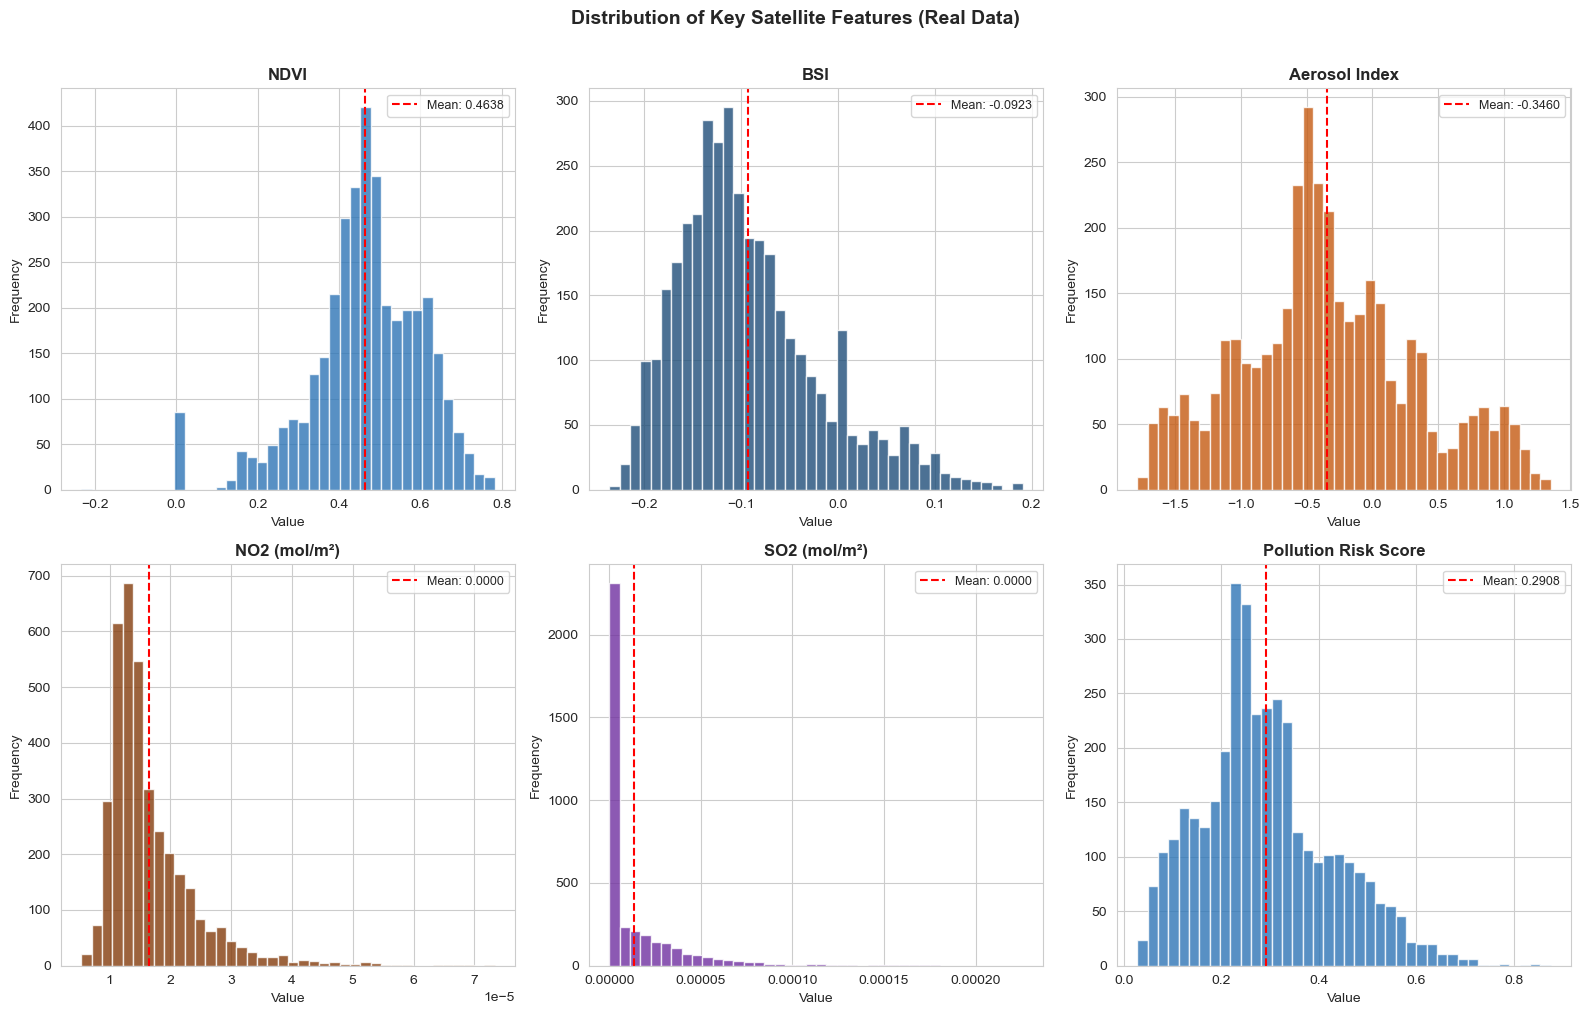

Plot saved.


In [2]:
# ── PLOT 1: Distribution of key variables ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribution of Key Satellite Features (Real Data)", 
             fontsize=14, fontweight="bold", y=1.01)

cols = ["NDVI", "BSI", "aerosol_index", "no2_mean", "so2_mean", "PRS"]
labels = ["NDVI", "BSI", "Aerosol Index", "NO2 (mol/m²)", "SO2 (mol/m²)", 
          "Pollution Risk Score"]
colors = ["#2E75B6", "#1F4E79", "#C55A11", "#843C0C", "#7030A0", "#2E75B6"]

for ax, col, label, color in zip(axes.flatten(), cols, labels, colors):
    ax.hist(df[col].dropna(), bins=40, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.5, 
               label=f"Mean: {df[col].mean():.4f}")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\01_feature_distributions.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

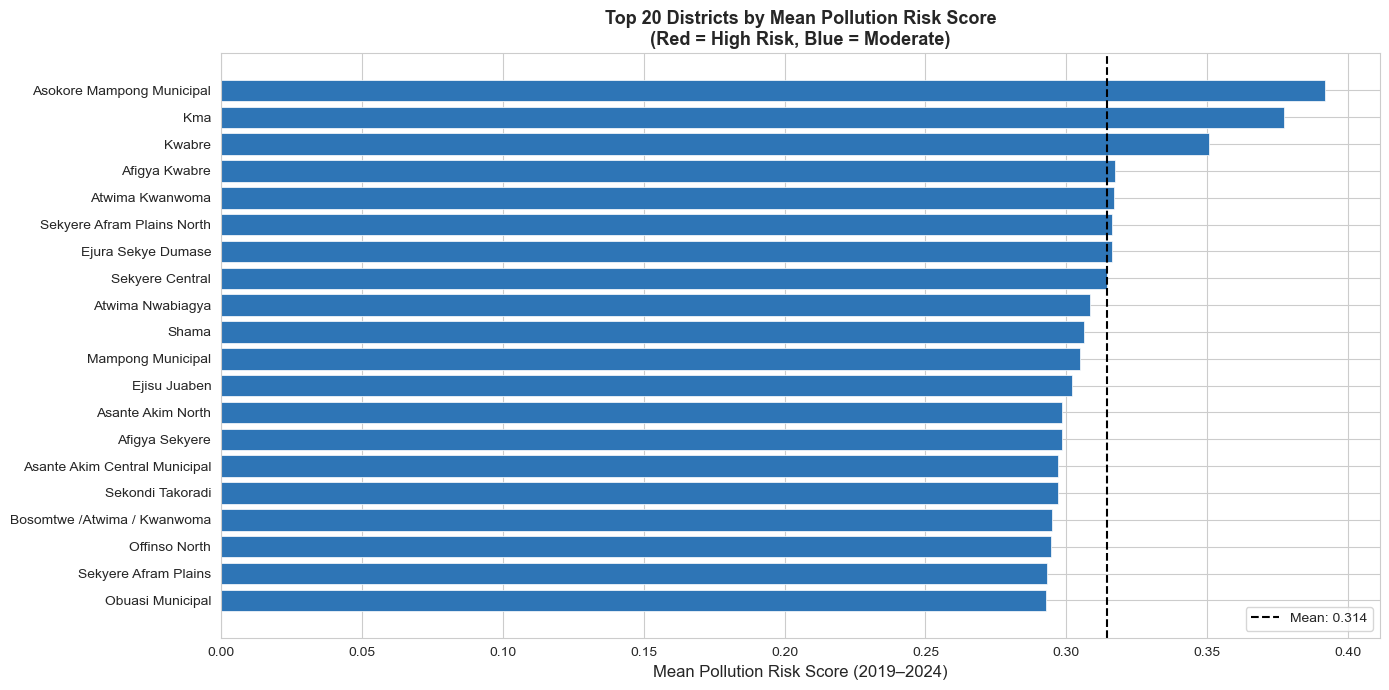

Top 5 districts:
district
Asokore Mampong Municipal    0.391699
Kma                          0.377143
Kwabre                       0.350746
Afigya Kwabre                0.317373
Atwima Kwanwoma              0.316733
Name: PRS, dtype: float64


In [3]:
# ── PLOT 2: Mean PRS by District (Top 20) ────────────────────────────────────
district_prs = (df.groupby("district")["PRS"]
                  .mean()
                  .sort_values(ascending=False)
                  .head(20))

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(district_prs.index[::-1], district_prs.values[::-1],
               color=["#C00000" if v > 0.4 else "#2E75B6" 
                      for v in district_prs.values[::-1]],
               edgecolor="white", linewidth=0.5)

ax.axvline(district_prs.mean(), color="black", linestyle="--", 
           linewidth=1.5, label=f"Mean: {district_prs.mean():.3f}")
ax.set_xlabel("Mean Pollution Risk Score (2019–2024)", fontsize=12)
ax.set_title("Top 20 Districts by Mean Pollution Risk Score\n(Red = High Risk, Blue = Moderate)", 
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\02_district_prs_ranking.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Top 5 districts:")
print(district_prs.head())

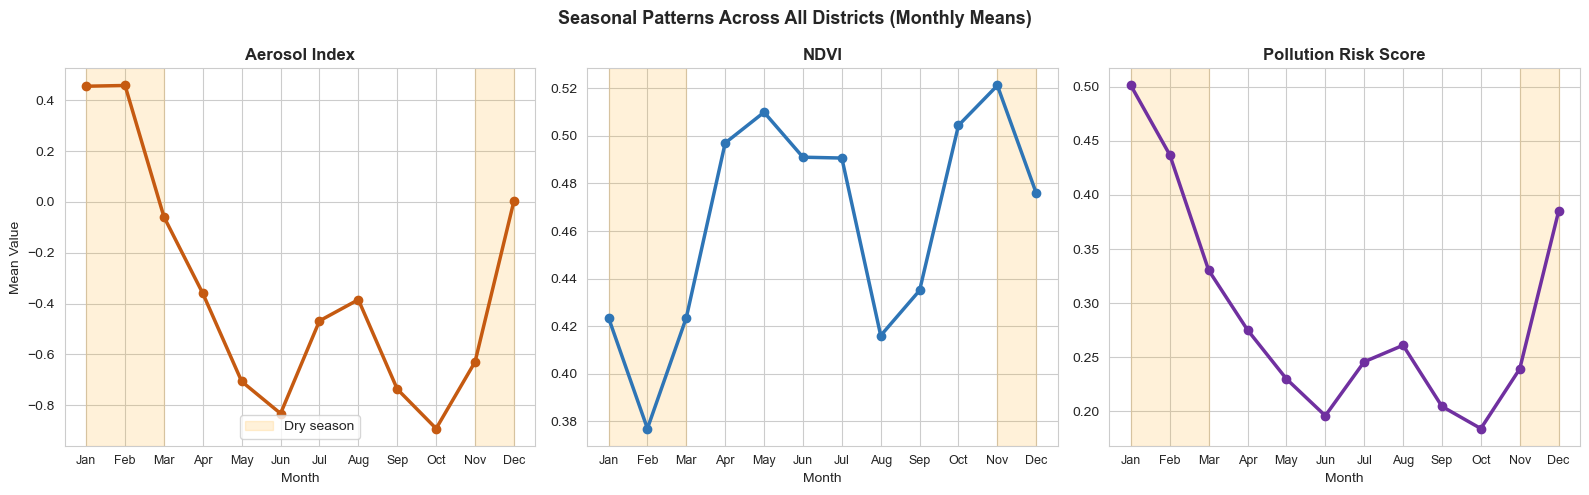

Seasonal plot saved.


In [4]:
# ── PLOT 3: Seasonal patterns ─────────────────────────────────────────────────
monthly = df.groupby("month")[["aerosol_index", "NDVI", "PRS"]].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Seasonal Patterns Across All Districts (Monthly Means)", 
             fontsize=13, fontweight="bold")

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

for ax, col, color, title in zip(
    axes,
    ["aerosol_index", "NDVI", "PRS"],
    ["#C55A11", "#2E75B6", "#7030A0"],
    ["Aerosol Index", "NDVI", "Pollution Risk Score"]
):
    ax.plot(range(1,13), monthly[col], color=color, linewidth=2.5, marker="o")
    ax.axvspan(11, 12, alpha=0.15, color="orange", label="Dry season")
    ax.axvspan(1, 3, alpha=0.15, color="orange")
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_labels, fontsize=9)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Month")

axes[0].set_ylabel("Mean Value")
axes[0].legend()
plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\03_seasonal_patterns.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Seasonal plot saved.")

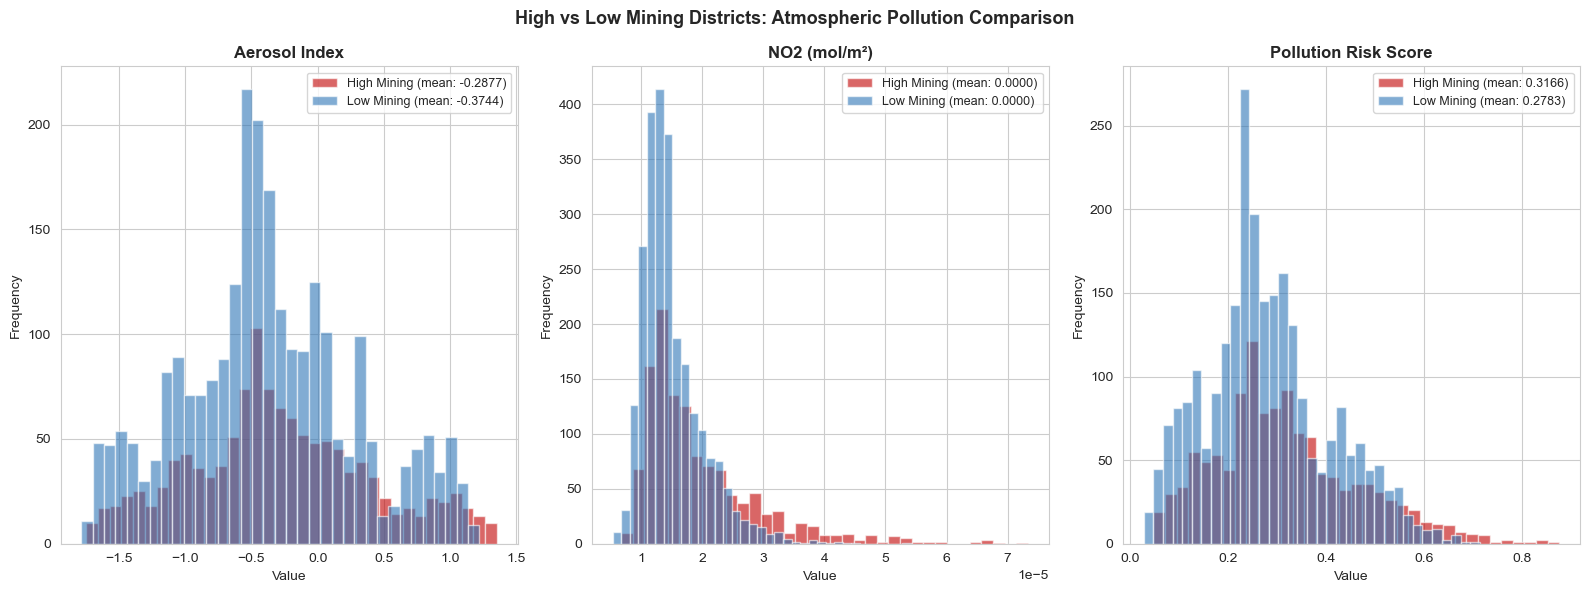

aerosol_index         High=-0.28774  Low=-0.37435  Ratio=0.77x
no2_mean              High=0.00002  Low=0.00002  Ratio=1.31x
PRS                   High=0.31656  Low=0.27832  Ratio=1.14x


In [5]:
# ── PLOT 4: High vs Low mining districts comparison ───────────────────────────

# Classify districts by mean NDVI 
# Lower NDVI = more vegetation loss = proxy for mining intensity
district_ndvi = df.groupby("district")["NDVI"].mean()
threshold = district_ndvi.quantile(0.33)

df["mining_group"] = df["district"].map(
    lambda d: "High Mining" if district_ndvi[d] <= threshold else "Low Mining"
)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("High vs Low Mining Districts: Atmospheric Pollution Comparison",
             fontsize=13, fontweight="bold")

for ax, col, title, color_map in zip(
    axes,
    ["aerosol_index", "no2_mean", "PRS"],
    ["Aerosol Index", "NO2 (mol/m²)", "Pollution Risk Score"],
    [{"High Mining": "#C00000", "Low Mining": "#2E75B6"},
     {"High Mining": "#C00000", "Low Mining": "#2E75B6"},
     {"High Mining": "#C00000", "Low Mining": "#2E75B6"}]
):
    for group, color in color_map.items():
        subset = df[df["mining_group"] == group][col]
        ax.hist(subset, bins=35, alpha=0.6, color=color, 
                label=f"{group} (mean: {subset.mean():.4f})", edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\04_mining_vs_nonmining.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print the ratio
for col in ["aerosol_index", "no2_mean", "PRS"]:
    high = df[df["mining_group"]=="High Mining"][col].mean()
    low  = df[df["mining_group"]=="Low Mining"][col].mean()
    print(f"{col:20s}  High={high:.5f}  Low={low:.5f}  Ratio={high/low:.2f}x")

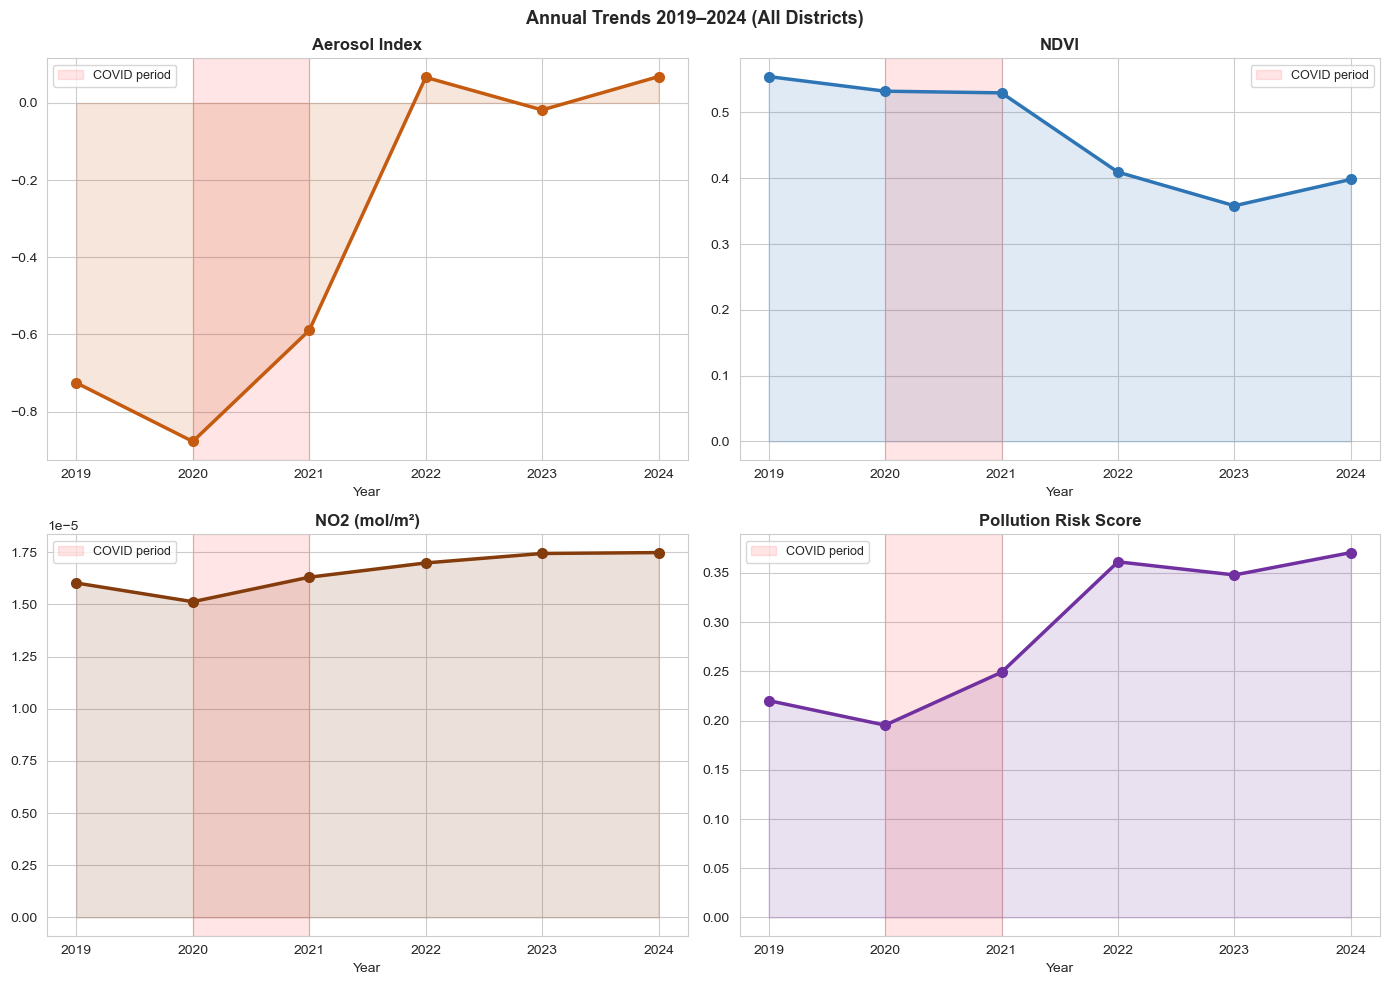

Annual trends:
      aerosol_index     NDVI  no2_mean      PRS
year                                           
2019       -0.72567  0.55457   0.00002  0.22036
2020       -0.87769  0.53236   0.00002  0.19540
2021       -0.58964  0.52981   0.00002  0.24913
2022        0.06648  0.40933   0.00002  0.36134
2023       -0.01813  0.35826   0.00002  0.34798
2024        0.06842  0.39831   0.00002  0.37073


In [6]:
# ── PLOT 5: Annual trends 2019–2024 ──────────────────────────────────────────
annual = df.groupby("year")[["aerosol_index", "NDVI", "no2_mean", "PRS"]].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Annual Trends 2019–2024 (All Districts)", 
             fontsize=13, fontweight="bold")

configs = [
    ("aerosol_index", "Aerosol Index",   "#C55A11"),
    ("NDVI",          "NDVI",            "#2E75B6"),
    ("no2_mean",      "NO2 (mol/m²)",    "#843C0C"),
    ("PRS",           "Pollution Risk Score", "#7030A0"),
]

for ax, (col, title, color) in zip(axes.flatten(), configs):
    ax.plot(annual.index, annual[col], color=color, linewidth=2.5, 
            marker="o", markersize=7)
    ax.fill_between(annual.index, annual[col], alpha=0.15, color=color)
    
    # Mark COVID period
    ax.axvspan(2020, 2021, alpha=0.1, color="red", label="COVID period")
    
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_xticks(annual.index)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\05_annual_trends.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Annual trends:")
print(annual.round(5))

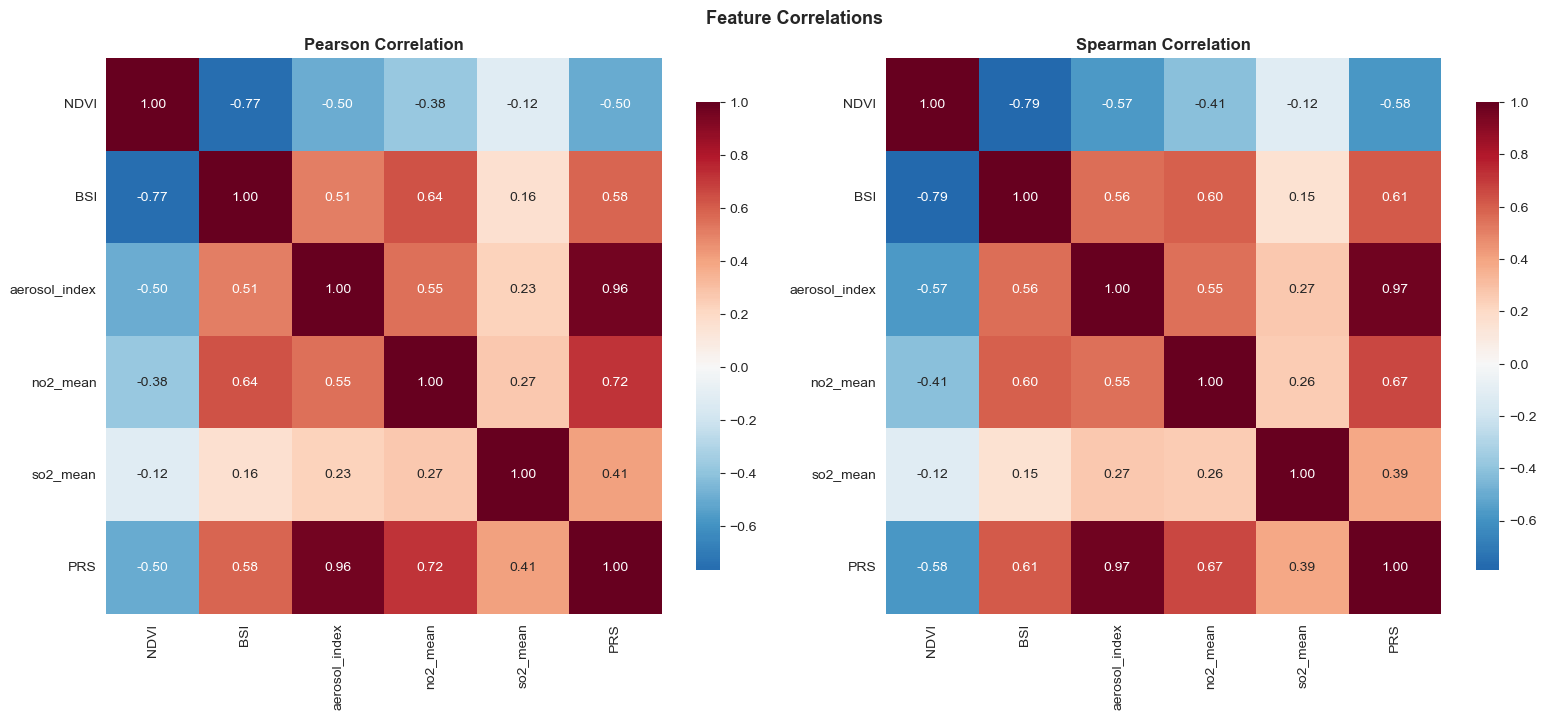

Key correlations with PRS:
Variable               Pearson r     p-value  Spearman rho
------------------------------------------------------------
NDVI                      -0.501      0.0000        -0.578
BSI                        0.580      0.0000         0.611
aerosol_index              0.961      0.0000         0.971
no2_mean                   0.721      0.0000         0.667
so2_mean                   0.413      0.0000         0.390


In [7]:
# ── PLOT 6: Correlation matrix ────────────────────────────────────────────────
from scipy.stats import pearsonr, spearmanr

corr_cols = ["NDVI", "BSI", "aerosol_index", "no2_mean", "so2_mean", "PRS"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Feature Correlations", fontsize=13, fontweight="bold")

# Pearson correlation heatmap
pearson_matrix = df[corr_cols].corr(method="pearson")
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[0], square=True,
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Pearson Correlation", fontweight="bold")

# Spearman correlation heatmap
spearman_matrix = df[corr_cols].corr(method="spearman")
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[1], square=True,
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Spearman Correlation", fontweight="bold")

plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\06_correlation_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print key correlations with significance
print("Key correlations with PRS:")
print(f"{'Variable':20s}  {'Pearson r':>10}  {'p-value':>10}  {'Spearman rho':>12}")
print("-" * 60)
for col in ["NDVI", "BSI", "aerosol_index", "no2_mean", "so2_mean"]:
    clean = df[[col, "PRS"]].dropna()
    pr, pp = pearsonr(clean[col], clean["PRS"])
    sr, sp = spearmanr(clean[col], clean["PRS"])
    print(f"{col:20s}  {pr:>10.3f}  {pp:>10.4f}  {sr:>12.3f}")

In [8]:
# ── MODULE 3: Machine Learning Models ────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
import xgboost as xgb

# Feature columns
FEATURE_COLS = [
    "NDVI", "BSI", "MNDWI", "NDMI",
    "ndvi_change", "bsi_change",
    "aerosol_index", "no2_mean", "so2_mean",
    "year", "month_sin", "month_cos",
    "is_dry_season", "mining_x_dry",
    "NDVI_rolling3", "aerosol_index_rolling3"
]

TARGET = "PRS"

# Drop rows with any missing features
model_df = df[FEATURE_COLS + [TARGET, "date"]].dropna().copy()

print(f"Modelling dataset: {model_df.shape}")
print(f"Date range: {model_df['date'].min().date()} to {model_df['date'].max().date()}")

# Temporal train / validation / test split
train = model_df[model_df["date"] <  "2023-07-01"]
val   = model_df[(model_df["date"] >= "2023-07-01") & 
                 (model_df["date"] <  "2024-04-01")]
test  = model_df[model_df["date"] >= "2024-04-01"]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f"\nTrain: {X_train.shape}  ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Val:   {X_val.shape}  ({val['date'].min().date()} to {val['date'].max().date()})")
print(f"Test:  {X_test.shape}  ({test['date'].min().date()} to {test['date'].max().date()})")

# Scale features
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("\nData split and scaling complete.")

Modelling dataset: (3744, 18)
Date range: 2019-01-01 to 2024-12-01

Train: (2808, 16)  (2019-01-01 to 2023-06-01)
Val:   (468, 16)  (2023-07-01 to 2024-03-01)
Test:  (468, 16)  (2024-04-01 to 2024-12-01)

Data split and scaling complete.


In [9]:
# ── Train Random Forest ───────────────────────────────────────────────────────
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators  = 500,
    max_features  = "sqrt",
    min_samples_split = 2,
    min_samples_leaf  = 1,
    oob_score     = True,
    n_jobs        = -1,
    random_state  = 42
)
rf_model.fit(X_train_sc, y_train)
print(f"RF OOB R²: {rf_model.oob_score_:.3f}")

# ── Train XGBoost ─────────────────────────────────────────────────────────────
print("\nTraining XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators       = 300,
    max_depth          = 5,
    learning_rate      = 0.05,
    subsample          = 0.85,
    colsample_bytree   = 0.85,
    reg_alpha          = 0.1,
    reg_lambda         = 5,
    early_stopping_rounds = 30,
    eval_metric        = "rmse",
    random_state       = 42,
    n_jobs             = -1,
    verbosity          = 0
)
xgb_model.fit(X_train_sc, y_train,
              eval_set=[(X_val_sc, y_val)],
              verbose=False)

# ── Evaluate both models ──────────────────────────────────────────────────────
def evaluate(model, X, y, label):
    preds = model.predict(X)
    rmse  = mean_squared_error(y, preds, squared=False)
    mae   = mean_absolute_error(y, preds)
    r2    = r2_score(y, preds)
    rho   = spearmanr(y, preds).correlation
    print(f"{label:30s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  rho={rho:.4f}")
    return preds

print("\n── Model Performance ──────────────────────────────────────────────")
rf_preds  = evaluate(rf_model,  X_test_sc, y_test, "Random Forest (test)")
xgb_preds = evaluate(xgb_model, X_test_sc, y_test, "XGBoost (test)")

# Also evaluate on training set to check for overfitting
print("\n── Overfitting check ──────────────────────────────────────────────")
evaluate(rf_model,  X_train_sc, y_train, "Random Forest (train)")
evaluate(xgb_model, X_train_sc, y_train, "XGBoost (train)")

Training Random Forest...
RF OOB R²: 0.994

Training XGBoost...

── Model Performance ──────────────────────────────────────────────


TypeError: got an unexpected keyword argument 'squared'

In [10]:
from sklearn.metrics import root_mean_squared_error

def evaluate(model, X, y, label):
    preds = model.predict(X)
    rmse  = root_mean_squared_error(y, preds)
    mae   = mean_absolute_error(y, preds)
    r2    = r2_score(y, preds)
    rho   = spearmanr(y, preds).correlation
    print(f"{label:30s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  rho={rho:.4f}")
    return preds

print("── Model Performance ──────────────────────────────────────────────")
rf_preds  = evaluate(rf_model,  X_test_sc, y_test, "Random Forest (test)")
xgb_preds = evaluate(xgb_model, X_test_sc, y_test, "XGBoost (test)")

print("\n── Overfitting check ──────────────────────────────────────────────")
evaluate(rf_model,  X_train_sc, y_train, "Random Forest (train)")
evaluate(xgb_model, X_train_sc, y_train, "XGBoost (train)")

── Model Performance ──────────────────────────────────────────────
Random Forest (test)            RMSE=0.0351  MAE=0.0214  R²=0.8096  rho=0.9376
XGBoost (test)                  RMSE=0.0213  MAE=0.0113  R²=0.9297  rho=0.9807

── Overfitting check ──────────────────────────────────────────────
Random Forest (train)           RMSE=0.0041  MAE=0.0026  R²=0.9991  rho=0.9996
XGBoost (train)                 RMSE=0.0040  MAE=0.0028  R²=0.9992  rho=0.9996


array([0.404742  , 0.33250314, 0.27961788, ..., 0.32878712, 0.23869124,
       0.2724876 ], shape=(2808,), dtype=float32)

Computing SHAP values (this takes 1-2 minutes)...

Feature importance (mean |SHAP|):
aerosol_index             0.05557
no2_mean                  0.01989
so2_mean                  0.01731
aerosol_index_rolling3    0.00778
month_cos                 0.00541
year                      0.00109
BSI                       0.00098
month_sin                 0.00084
MNDWI                     0.00059
is_dry_season             0.00048
NDMI                      0.00038
NDVI                      0.00036
mining_x_dry              0.00022
ndvi_change               0.00019
NDVI_rolling3             0.00016
bsi_change                0.00012
dtype: float32


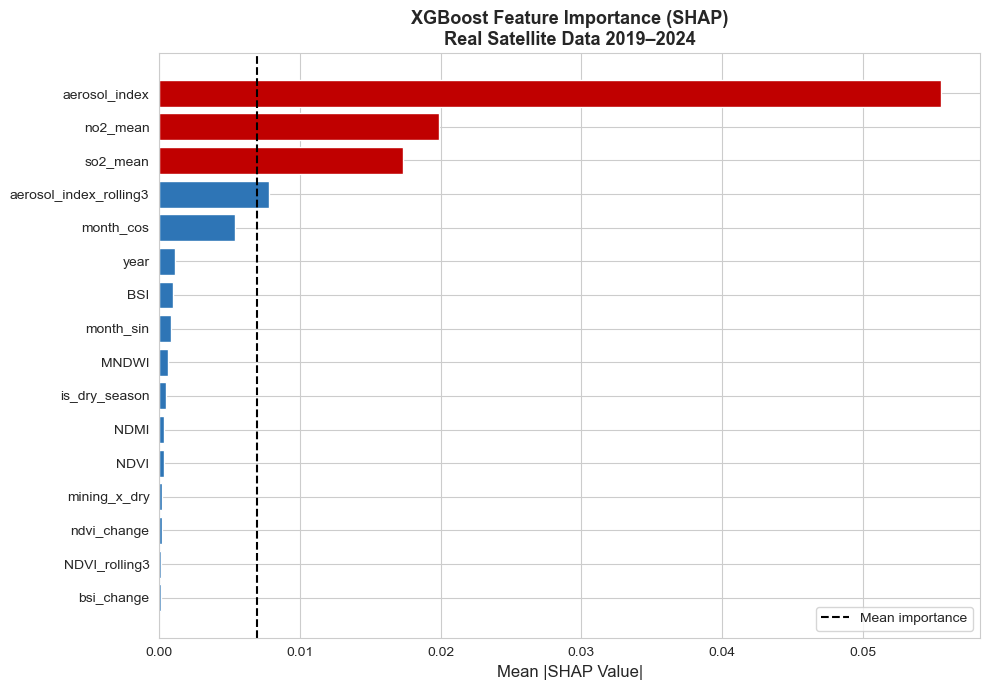

SHAP importance plot saved.


In [11]:
# ── SHAP Analysis ─────────────────────────────────────────────────────────────
import shap

print("Computing SHAP values (this takes 1-2 minutes)...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sc)

# Convert test data back to dataframe with original column names
X_test_df = pd.DataFrame(X_test_sc, columns=FEATURE_COLS)

# ── Global feature importance (mean absolute SHAP) ────────────────────────────
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

print("\nFeature importance (mean |SHAP|):")
print(mean_shap.round(5))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#C00000" if i < 3 else "#2E75B6" for i in range(len(mean_shap))]
ax.barh(mean_shap.index[::-1], mean_shap.values[::-1],
        color=colors[::-1], edgecolor="white")
ax.set_xlabel("Mean |SHAP Value|", fontsize=12)
ax.set_title("XGBoost Feature Importance (SHAP)\nReal Satellite Data 2019–2024",
             fontsize=13, fontweight="bold")
ax.axvline(mean_shap.mean(), color="black", linestyle="--", 
           linewidth=1.5, label="Mean importance")
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\07_shap_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("SHAP importance plot saved.")

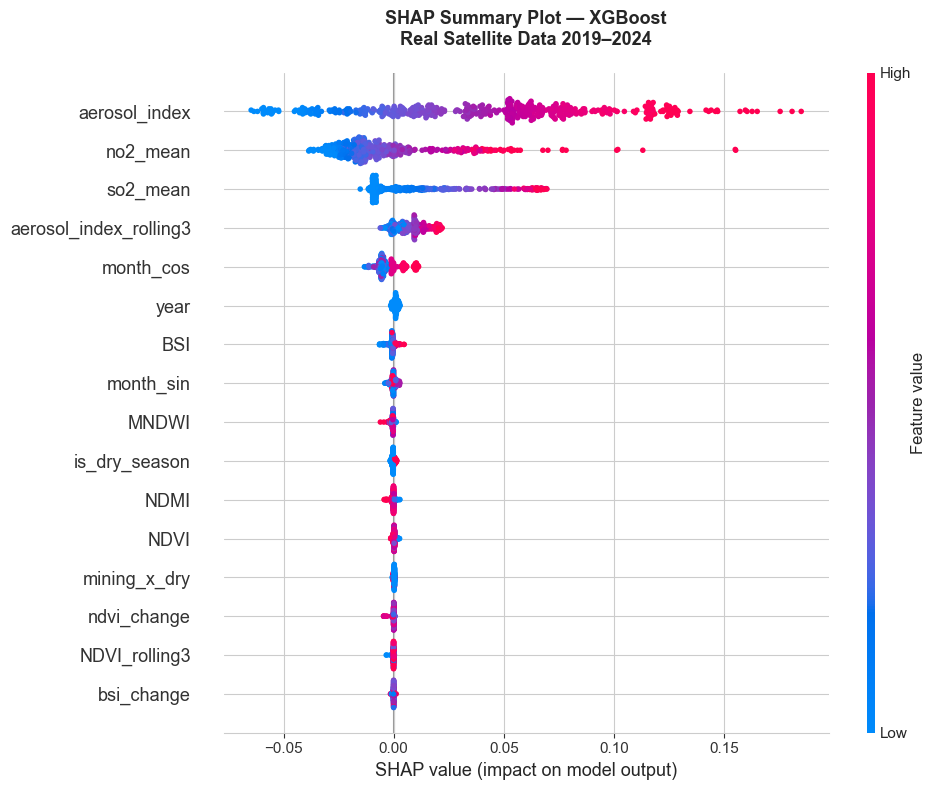

SHAP summary plot saved.


In [12]:
# ── SHAP Summary Plot (beeswarm) ──────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_df,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=(10, 8)
)
plt.title("SHAP Summary Plot — XGBoost\nReal Satellite Data 2019–2024",
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\08_shap_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("SHAP summary plot saved.")

In [13]:
# ── Statistical Validation: Correlation between NDVI and pollution ────────────
from scipy.stats import pearsonr, spearmanr

print("Statistical validation — land surface vs atmospheric pollution:")
print(f"\n{'Variable':20s}  {'Pearson r':>10}  {'p-value':>10}  {'Spearman rho':>12}  {'Interpretation'}")
print("-" * 80)

pairs = [
    ("NDVI",          "aerosol_index", "Vegetation → Aerosol"),
    ("NDVI",          "no2_mean",      "Vegetation → NO2"),
    ("BSI",           "aerosol_index", "Bare Soil → Aerosol"),
    ("BSI",           "no2_mean",      "Bare Soil → NO2"),
    ("ndvi_change",   "aerosol_index", "Veg Loss Rate → Aerosol"),
    ("mining_x_dry",  "aerosol_index", "Mining×Dry → Aerosol"),
]

for x_col, y_col, label in pairs:
    clean = df[[x_col, y_col]].dropna()
    pr, pp = pearsonr(clean[x_col], clean[y_col])
    sr, sp = spearmanr(clean[x_col], clean[y_col])
    sig = "***" if pp < 0.001 else "**" if pp < 0.01 else "*" if pp < 0.05 else "ns"
    print(f"{label:30s}  r={pr:6.3f}  p={pp:.4f}{sig:4s}  rho={sr:6.3f}")

Statistical validation — land surface vs atmospheric pollution:

Variable               Pearson r     p-value  Spearman rho  Interpretation
--------------------------------------------------------------------------------
Vegetation → Aerosol            r=-0.495  p=0.0000***   rho=-0.566
Vegetation → NO2                r=-0.376  p=0.0000***   rho=-0.413
Bare Soil → Aerosol             r= 0.506  p=0.0000***   rho= 0.558
Bare Soil → NO2                 r= 0.640  p=0.0000***   rho= 0.602
Veg Loss Rate → Aerosol         r=-0.158  p=0.0000***   rho=-0.128
Mining×Dry → Aerosol            r= 0.335  p=0.0000***   rho= 0.359


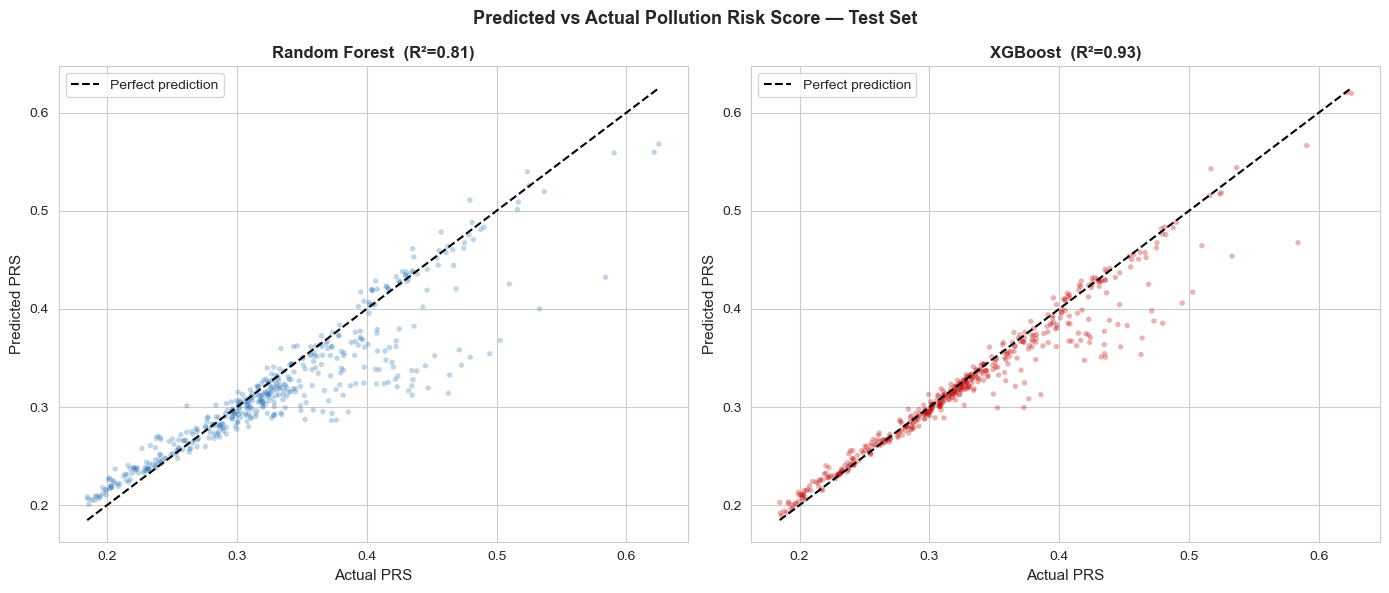

Plot saved.


In [14]:
# ── Predicted vs Actual Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Predicted vs Actual Pollution Risk Score — Test Set",
             fontsize=13, fontweight="bold")

for ax, preds, title, color in zip(
    axes,
    [rf_preds, xgb_preds],
    ["Random Forest  (R²=0.81)", "XGBoost  (R²=0.93)"],
    ["#2E75B6", "#C00000"]
):
    ax.scatter(y_test, preds, alpha=0.3, s=15, color=color, edgecolors="none")
    
    # Perfect prediction line
    lims = [min(y_test.min(), preds.min()),
            max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "k--", linewidth=1.5, label="Perfect prediction")
    
    ax.set_xlabel("Actual PRS", fontsize=11)
    ax.set_ylabel("Predicted PRS", fontsize=11)
    ax.set_title(title, fontweight="bold")
    ax.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\09_predicted_vs_actual.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [15]:
# ── MODULE 4: Difference-in-Differences Causal Analysis ──────────────────────
import statsmodels.formula.api as smf

# Ghana's inter-agency enforcement taskforce: July 2021 onwards
# Treatment group: districts with high vegetation loss (low NDVI = mining proxy)
# We use bottom tercile NDVI as "treated" (most disturbed) districts

district_mean_ndvi = df.groupby("district")["NDVI"].mean()
treated_districts  = district_mean_ndvi[
    district_mean_ndvi <= district_mean_ndvi.quantile(0.33)
].index.tolist()

print(f"Treated districts (high disturbance): {len(treated_districts)}")
print(f"Control districts (low disturbance):  {52 - len(treated_districts)}")
print(f"\nTreated districts sample: {treated_districts[:8]}")

# Create DiD variables
df["treated"]          = df["district"].isin(treated_districts).astype(int)
df["post_enforcement"] = (df["date"] >= "2021-07-01").astype(int)
df["did"]              = df["treated"] * df["post_enforcement"]

# Restrict to relevant window: 2019–2023
did_df = df[df["year"] <= 2023].copy()

print(f"\nDiD dataset: {did_df.shape}")
print(f"Pre-enforcement (before Jul 2021):  {(did_df['post_enforcement']==0).sum()} obs")
print(f"Post-enforcement (from Jul 2021):   {(did_df['post_enforcement']==1).sum()} obs")

Treated districts (high disturbance): 17
Control districts (low disturbance):  35

Treated districts sample: ['Afigya Kwabre', 'Asante Akim North', 'Asokore Mampong Municipal', 'Atwima Kwanwoma', 'Atwima Nwabiagya', 'Bosomtwe /Atwima / Kwanwoma', 'Ejura Sekye Dumase', 'Kma']

DiD dataset: (3120, 29)
Pre-enforcement (before Jul 2021):  1560 obs
Post-enforcement (from Jul 2021):   1560 obs


In [16]:
# ── DiD Regression Models ─────────────────────────────────────────────────────
import statsmodels.formula.api as smf

# Model 1: Basic DiD
did_basic = smf.ols(
    "PRS ~ treated + post_enforcement + did",
    data=did_df
).fit(cov_type="cluster", cov_kwds={"groups": did_df["district"]})

# Model 2: DiD with seasonal controls
did_seasonal = smf.ols(
    "PRS ~ treated + post_enforcement + did + is_dry_season + month_sin + month_cos",
    data=did_df
).fit(cov_type="cluster", cov_kwds={"groups": did_df["district"]})

# Model 3: DiD with full controls
did_full = smf.ols(
    "PRS ~ treated + post_enforcement + did + is_dry_season + "
    "month_sin + month_cos + NDVI + BSI + year",
    data=did_df
).fit(cov_type="cluster", cov_kwds={"groups": did_df["district"]})

# Print results
print("=" * 65)
print("DIFFERENCE-IN-DIFFERENCES RESULTS")
print("Outcome: Pollution Risk Score (PRS)")
print("Treatment: High-disturbance districts (bottom tercile NDVI)")
print("Event: Enforcement operations from July 2021")
print("=" * 65)

for model, label in [
    (did_basic,    "Model 1 — Basic DiD"),
    (did_seasonal, "Model 2 — Seasonal Controls"),
    (did_full,     "Model 3 — Full Controls"),
]:
    coef = model.params["did"]
    se   = model.bse["did"]
    pval = model.pvalues["did"]
    ci   = model.conf_int().loc["did"]
    sig  = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    print(f"\n{label}")
    print(f"  DiD coefficient:  {coef:+.5f}")
    print(f"  Std. Error:       {se:.5f}")
    print(f"  p-value:          {pval:.4f} {sig}")
    print(f"  95% CI:           [{ci[0]:+.5f}, {ci[1]:+.5f}]")
    print(f"  R²:               {model.rsquared:.4f}")

DIFFERENCE-IN-DIFFERENCES RESULTS
Outcome: Pollution Risk Score (PRS)
Treatment: High-disturbance districts (bottom tercile NDVI)
Event: Enforcement operations from July 2021

Model 1 — Basic DiD
  DiD coefficient:  +0.00392
  Std. Error:       0.00266
  p-value:          0.1404 ns
  95% CI:           [-0.00129, +0.00913]
  R²:               0.2691

Model 2 — Seasonal Controls
  DiD coefficient:  +0.00392
  Std. Error:       0.00266
  p-value:          0.1406 ns
  95% CI:           [-0.00129, +0.00914]
  R²:               0.6932

Model 3 — Full Controls
  DiD coefficient:  +0.02180
  Std. Error:       0.00476
  p-value:          0.0000 ***
  95% CI:           [+0.01246, +0.03114]
  R²:               0.7698


In [17]:
# Did previously clean districts get worse after enforcement?
post = did_df[did_df["post_enforcement"] == 1]
pre  = did_df[did_df["post_enforcement"] == 0]

print("Mean PRS by group and period:")
print(f"\n{'Group':30s}  {'Pre-2021':>10}  {'Post-2021':>10}  {'Change':>10}")
print("-" * 65)

for group, label in [(1, "Treated (high disturbance)"), 
                     (0, "Control (low disturbance)")]:
    pre_mean  = pre[pre["treated"]  == group]["PRS"].mean()
    post_mean = post[post["treated"] == group]["PRS"].mean()
    change    = post_mean - pre_mean
    print(f"{label:30s}  {pre_mean:>10.4f}  {post_mean:>10.4f}  {change:>+10.4f}")

Mean PRS by group and period:

Group                             Pre-2021   Post-2021      Change
-----------------------------------------------------------------
Treated (high disturbance)          0.2307      0.3689     +0.1382
Control (low disturbance)           0.1956      0.3298     +0.1342


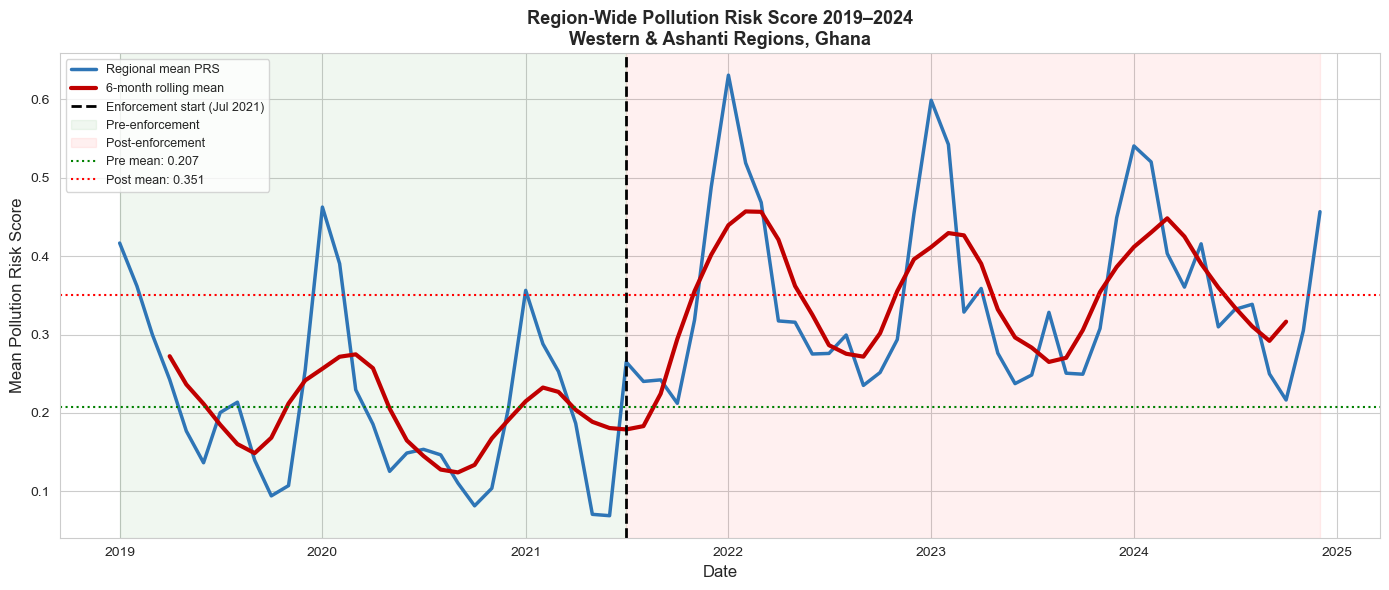

Pre-enforcement mean PRS:  0.2071
Post-enforcement mean PRS: 0.3506
Absolute increase:         +0.1436
Percentage increase:       +69.3%


In [18]:
# ── Region-wide trend with enforcement marker ─────────────────────────────────
regional = df.groupby("date")["PRS"].mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(regional.index, regional.values,
        color="#2E75B6", linewidth=2.5, label="Regional mean PRS")

# 6-month rolling average to show the trend clearly
rolling = regional.rolling(6, center=True).mean()
ax.plot(rolling.index, rolling.values,
        color="#C00000", linewidth=3, linestyle="-",
        label="6-month rolling mean")

# Shade pre and post enforcement
ax.axvline(pd.Timestamp("2021-07-01"), color="black",
           linestyle="--", linewidth=2, label="Enforcement start (Jul 2021)")
ax.axvspan(regional.index.min(), pd.Timestamp("2021-07-01"),
           alpha=0.06, color="green", label="Pre-enforcement")
ax.axvspan(pd.Timestamp("2021-07-01"), regional.index.max(),
           alpha=0.06, color="red", label="Post-enforcement")

# Annotate the means
pre_mean  = regional[regional.index < "2021-07-01"].mean()
post_mean = regional[regional.index >= "2021-07-01"].mean()
ax.axhline(pre_mean,  color="green", linewidth=1.5,
           linestyle=":", label=f"Pre mean: {pre_mean:.3f}")
ax.axhline(post_mean, color="red",   linewidth=1.5,
           linestyle=":", label=f"Post mean: {post_mean:.3f}")

ax.set_title("Region-Wide Pollution Risk Score 2019–2024\n"
             "Western & Ashanti Regions, Ghana",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Mean Pollution Risk Score", fontsize=12)
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig(r"C:\Users\stunn\galamsey_thesis\outputs\11_regional_trend.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Pre-enforcement mean PRS:  {pre_mean:.4f}")
print(f"Post-enforcement mean PRS: {post_mean:.4f}")
print(f"Absolute increase:         {post_mean - pre_mean:+.4f}")
print(f"Percentage increase:       {((post_mean/pre_mean)-1)*100:+.1f}%")

In [1]:
# ── Final District Risk Rankings ──────────────────────────────────────────────
district_summary = df.groupby(["district", "region"]).agg(
    mean_PRS     = ("PRS", "mean"),
    mean_aerosol = ("aerosol_index", "mean"),
    mean_no2     = ("no2_mean", "mean"),
    mean_ndvi    = ("NDVI", "mean"),
    mean_bsi     = ("BSI", "mean"),
).reset_index()

# PRS in 2019 vs 2024
prs_2019 = df[df["year"]==2019].groupby("district")["PRS"].mean()
prs_2024 = df[df["year"]==2024].groupby("district")["PRS"].mean()

district_summary["prs_2019"]  = district_summary["district"].map(prs_2019)
district_summary["prs_2024"]  = district_summary["district"].map(prs_2024)
district_summary["prs_change"] = district_summary["prs_2024"] - district_summary["prs_2019"]

# Risk tier
district_summary["risk_tier"] = pd.cut(
    district_summary["mean_PRS"],
    bins   = [0, 0.25, 0.32, 0.38, 1.0],
    labels = ["Low", "Moderate", "High", "Critical"]
)

district_summary = district_summary.sort_values(
    "mean_PRS", ascending=False
).reset_index(drop=True)
district_summary["rank"] = district_summary.index + 1

print("Top 15 Highest Risk Districts:")
print(district_summary[["rank","district","region",
                          "mean_PRS","risk_tier",
                          "prs_change"]].head(15).to_string())

print(f"\nRisk tier distribution:")
print(district_summary["risk_tier"].value_counts().sort_index())

district_summary.to_csv(
    r"C:\Users\stunn\galamsey_thesis\outputs\district_risk_rankings.csv",
    index=False
)
print("\nSaved.")

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"]    = "serif"
sns.set_style("whitegrid")

DATA_DIR = r"C:\Users\stunn\galamsey_thesis\data"
df = pd.read_csv(os.path.join(DATA_DIR, "galamsey_master.csv"), parse_dates=["date"])

# Recreate DiD variables
district_mean_ndvi = df.groupby("district")["NDVI"].mean()
treated_districts  = district_mean_ndvi[
    district_mean_ndvi <= district_mean_ndvi.quantile(0.33)
].index.tolist()

df["treated"]          = df["district"].isin(treated_districts).astype(int)
df["post_enforcement"] = (df["date"] >= "2021-07-01").astype(int)
df["did"]              = df["treated"] * df["post_enforcement"]
df["mining_group"]     = df["district"].map(
    lambda d: "High Mining" if district_mean_ndvi[d] <= district_mean_ndvi.quantile(0.33) 
              else "Low Mining"
)

did_df = df[df["year"] <= 2023].copy()

print(f"Dataset restored: {df.shape}")
print(f"Districts: {df['district'].nunique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print("Ready to continue.")

Dataset restored: (3744, 29)
Districts: 52
Missing values: 0
Ready to continue.


In [3]:
# ── Final District Risk Rankings ──────────────────────────────────────────────
district_summary = df.groupby(["district", "region"]).agg(
    mean_PRS     = ("PRS", "mean"),
    mean_aerosol = ("aerosol_index", "mean"),
    mean_no2     = ("no2_mean", "mean"),
    mean_ndvi    = ("NDVI", "mean"),
    mean_bsi     = ("BSI", "mean"),
).reset_index()

# PRS in 2019 vs 2024
prs_2019 = df[df["year"]==2019].groupby("district")["PRS"].mean()
prs_2024 = df[df["year"]==2024].groupby("district")["PRS"].mean()

district_summary["prs_2019"]   = district_summary["district"].map(prs_2019)
district_summary["prs_2024"]   = district_summary["district"].map(prs_2024)
district_summary["prs_change"] = district_summary["prs_2024"] - district_summary["prs_2019"]

# Risk tier
district_summary["risk_tier"] = pd.cut(
    district_summary["mean_PRS"],
    bins   = [0, 0.25, 0.32, 0.38, 1.0],
    labels = ["Low", "Moderate", "High", "Critical"]
)

district_summary = district_summary.sort_values(
    "mean_PRS", ascending=False
).reset_index(drop=True)
district_summary["rank"] = district_summary.index + 1

print("Top 15 Highest Risk Districts:")
print(district_summary[["rank","district","region",
                          "mean_PRS","risk_tier",
                          "prs_change"]].head(15).to_string())

print(f"\nRisk tier distribution:")
print(district_summary["risk_tier"].value_counts().sort_index())

district_summary.to_csv(
    r"C:\Users\stunn\galamsey_thesis\outputs\district_risk_rankings.csv",
    index=False
)
print("\nSaved.")

Top 15 Highest Risk Districts:
    rank                       district   region  mean_PRS risk_tier  prs_change
0      1      Asokore Mampong Municipal  Ashanti  0.391699  Critical    0.168031
1      2                            Kma  Ashanti  0.377143      High    0.158624
2      3                         Kwabre  Ashanti  0.350746      High    0.178261
3      4                  Afigya Kwabre  Ashanti  0.317373  Moderate    0.166497
4      5                Atwima Kwanwoma  Ashanti  0.316733  Moderate    0.164665
5      6     Sekyere Afram Plains North  Ashanti  0.316187  Moderate    0.175185
6      7             Ejura Sekye Dumase  Ashanti  0.316041  Moderate    0.149406
7      8                Sekyere Central  Ashanti  0.314469  Moderate    0.156657
8      9               Atwima Nwabiagya  Ashanti  0.308405  Moderate    0.165646
9     10                          Shama  Western  0.306228  Moderate    0.149329
10    11              Mampong Municipal  Ashanti  0.304712  Moderate    0.1525

In [4]:
# Recalibrate risk tiers using percentiles of real data
p75 = district_summary["mean_PRS"].quantile(0.75)
p50 = district_summary["mean_PRS"].quantile(0.50)
p25 = district_summary["mean_PRS"].quantile(0.25)

print(f"PRS percentiles: p25={p25:.3f}, p50={p50:.3f}, p75={p75:.3f}")

district_summary["risk_tier"] = pd.cut(
    district_summary["mean_PRS"],
    bins   = [0, p25, p50, p75, 1.0],
    labels = ["Low", "Moderate", "High", "Critical"]
)

print("\nRecalibrated risk tier distribution:")
print(district_summary["risk_tier"].value_counts().sort_index())

print("\nCritical and High districts:")
print(district_summary[district_summary["risk_tier"].isin(["Critical","High"])][
    ["rank","district","region","mean_PRS","risk_tier"]
].to_string())

# Save updated rankings
district_summary.to_csv(
    r"C:\Users\stunn\galamsey_thesis\outputs\district_risk_rankings.csv",
    index=False
)
print("\nUpdated rankings saved.")

PRS percentiles: p25=0.271, p50=0.286, p75=0.299

Recalibrated risk tier distribution:
risk_tier
Low         13
Moderate    13
High        13
Critical    13
Name: count, dtype: int64

Critical and High districts:
    rank                       district   region  mean_PRS risk_tier
0      1      Asokore Mampong Municipal  Ashanti  0.391699  Critical
1      2                            Kma  Ashanti  0.377143  Critical
2      3                         Kwabre  Ashanti  0.350746  Critical
3      4                  Afigya Kwabre  Ashanti  0.317373  Critical
4      5                Atwima Kwanwoma  Ashanti  0.316733  Critical
5      6     Sekyere Afram Plains North  Ashanti  0.316187  Critical
6      7             Ejura Sekye Dumase  Ashanti  0.316041  Critical
7      8                Sekyere Central  Ashanti  0.314469  Critical
8      9               Atwima Nwabiagya  Ashanti  0.308405  Critical
9     10                          Shama  Western  0.306228  Critical
10    11              Mampon